# 🗂️ NB6 — Open-Meteo Archive API
**Source:** `https://archive-api.open-meteo.com/v1/archive`  
**Protocol:** HTTP GET  
**Schedule:** Once per event (establishes pre-event weather baseline)  
**Auth:** None

Fetches 30 days of historical daily weather at the epicentre. Used to understand the pre-event baseline — whether ground was already saturated from prior rainfall, which increases post-earthquake landslide risk.

In [1]:
! pip install requests pandas matplotlib --quiet


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
import urllib.parse

HEADERS = {"User-Agent": "EQMonitor/1.0"}

LAT, LON = -17.7134, 178.0650
EVENT_DATE = datetime.date(2026, 4, 23)  # date of EMSC event
LOOKBACK_DAYS = 30

WMO_CODES = {
    0:"Clear sky",1:"Mainly clear",2:"Partly cloudy",3:"Overcast",
    45:"Fog",61:"Rain",63:"Moderate rain",65:"Heavy rain",
    80:"Showers",95:"Thunderstorm",
}
print("✅ Config ready")

✅ Config ready


## Fetch 30-Day Historical Archive

In [3]:
start_date = (EVENT_DATE - datetime.timedelta(days=LOOKBACK_DAYS)).isoformat()
end_date   = (EVENT_DATE - datetime.timedelta(days=1)).isoformat()

params = urllib.parse.urlencode({
    "latitude":   LAT,
    "longitude":  LON,
    "timezone":   "auto",
    "start_date": start_date,
    "end_date":   end_date,
    "daily":      "temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,weathercode",
})
URL = f"https://archive-api.open-meteo.com/v1/archive?{params}"
print(f"Querying: {URL[:100]}...")
print(f"Period:   {start_date} → {end_date}")

r = requests.get(URL, timeout=15, headers=HEADERS)
r.raise_for_status()
data = r.json()
print(f"✅ Response: HTTP {r.status_code}")

Querying: https://archive-api.open-meteo.com/v1/archive?latitude=-17.7134&longitude=178.065&timezone=auto&star...
Period:   2026-03-24 → 2026-04-22
✅ Response: HTTP 200


## Parse Response

In [4]:
d = data["daily"]
df = pd.DataFrame({
    "date":     pd.to_datetime(d["time"]),
    "tmax":     d["temperature_2m_max"],
    "tmin":     d["temperature_2m_min"],
    "precip":   d["precipitation_sum"],
    "wind_max": d["windspeed_10m_max"],
    "code":     d["weathercode"],
})
df["conditions"] = df["code"].map(lambda x: WMO_CODES.get(x, f"Code {x}"))
df["tmean"] = (df["tmax"] + df["tmin"]) / 2

print(f"✅ Parsed {len(df)} daily rows\n")
print("30-day statistics:")
print(f"  Avg max temp:      {df['tmax'].mean():.1f}°C")
print(f"  Avg min temp:      {df['tmin'].mean():.1f}°C")
print(f"  Total precipitation: {df['precip'].sum():.1f} mm")
print(f"  Max daily precip:  {df['precip'].max():.1f} mm on {df.loc[df['precip'].idxmax(),'date'].date()}")
print(f"  Avg wind max:      {df['wind_max'].mean():.1f} km/h")
df.tail()

✅ Parsed 30 daily rows

30-day statistics:
  Avg max temp:      27.2°C
  Avg min temp:      21.6°C
  Total precipitation: 358.8 mm
  Max daily precip:  115.9 mm on 2026-04-07
  Avg wind max:      13.4 km/h


,date,tmax,tmin,precip,wind_max,code,conditions,tmean
25,2026-04-18,27.6,21.2,4.8,10.2,61,Rain,24.40
26,2026-04-19,27.3,21.3,8.5,9.7,63,Moderate rain,24.30
27,2026-04-20,28.2,22.1,2.8,11.2,55,Code 55,25.15
28,2026-04-21,28.6,21.9,0.8,10.2,51,Code 51,25.25
29,2026-04-22,28.0,21.3,4.9,7.0,55,Code 55,24.65


## Soil Saturation Proxy

Cumulative rainfall in the 7 days before the event is a proxy for soil saturation, which amplifies landslide risk after shallow earthquakes.

In [5]:
precip_7d  = df["precip"].tail(7).sum()
precip_30d = df["precip"].sum()
sat_level  = ("HIGH" if precip_7d > 50 else
              "MODERATE" if precip_7d > 20 else "LOW")

print(f"Pre-event rainfall:")
print(f"  Last 7 days:  {precip_7d:.1f} mm")
print(f"  Last 30 days: {precip_30d:.1f} mm")
print(f"  Soil saturation proxy: {sat_level}")

Pre-event rainfall:
  Last 7 days:  53.9 mm
  Last 30 days: 358.8 mm
  Soil saturation proxy: HIGH


## Visualise

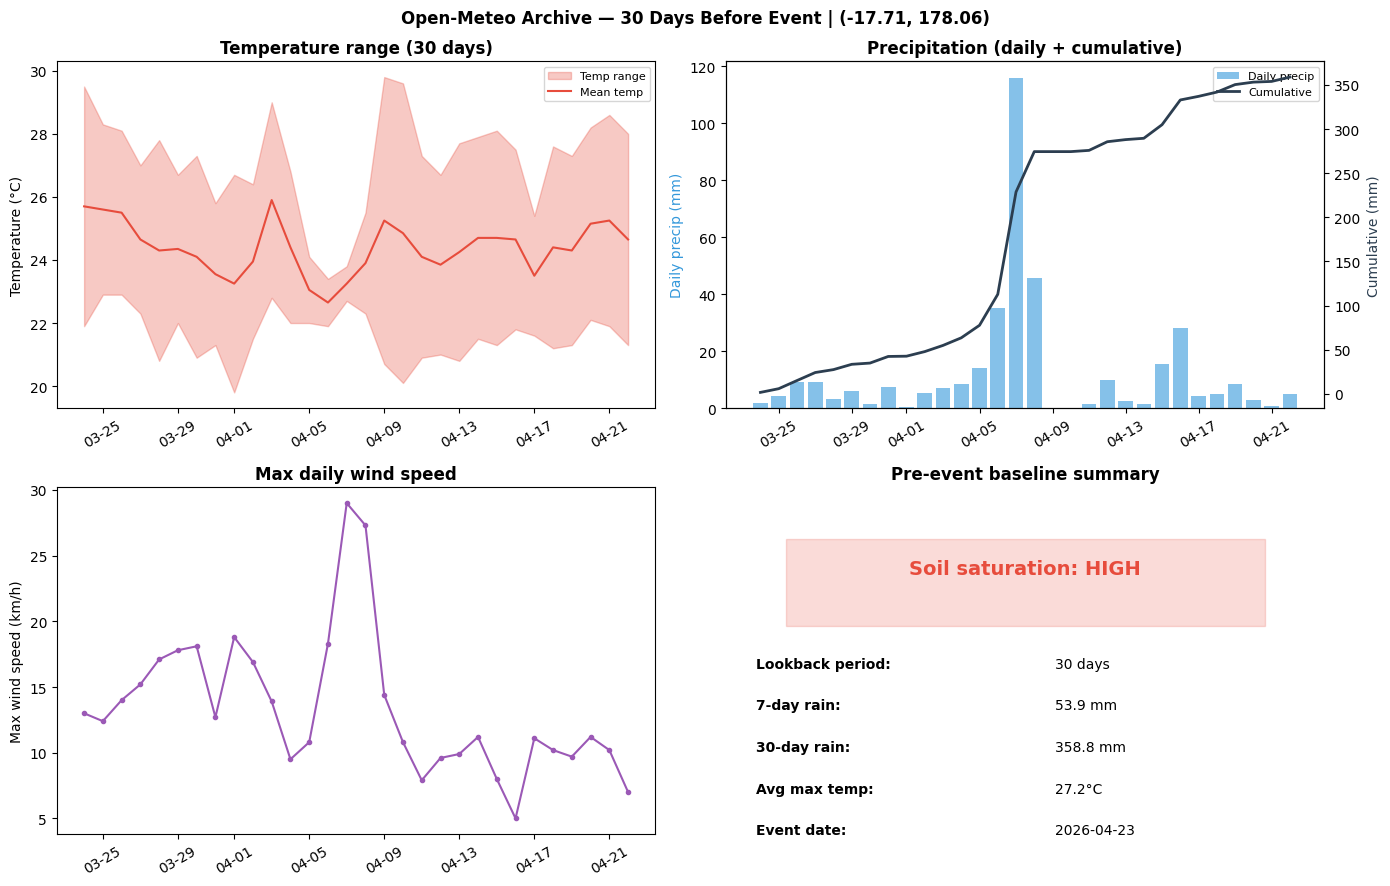

📊 Saved as nb6_openmeteo_archive_result.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f"Open-Meteo Archive — 30 Days Before Event | ({LAT:.2f}, {LON:.2f})",
             fontsize=12, fontweight='bold')

# 1. Temperature range
ax = axes[0,0]
ax.fill_between(df["date"], df["tmin"], df["tmax"], alpha=0.3, color='#e74c3c', label='Temp range')
ax.plot(df["date"], df["tmean"], color='#e74c3c', linewidth=1.5, label='Mean temp')
ax.set_ylabel("Temperature (°C)"); ax.legend(fontsize=8)
ax.set_title("Temperature range (30 days)", fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

# 2. Daily precipitation + cumulative
ax = axes[0,1]; ax2 = ax.twinx()
ax.bar(df["date"], df["precip"], color='#3498db', alpha=0.6, width=0.8, label='Daily precip')
ax2.plot(df["date"], df["precip"].cumsum(), color='#2c3e50', linewidth=2, label='Cumulative')
ax.set_ylabel("Daily precip (mm)", color='#3498db')
ax2.set_ylabel("Cumulative (mm)", color='#2c3e50')
ax.set_title("Precipitation (daily + cumulative)", fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
l1,la1=ax.get_legend_handles_labels(); l2,la2=ax2.get_legend_handles_labels()
ax.legend(l1+l2,la1+la2,fontsize=8)

# 3. Wind speed
ax = axes[1,0]
ax.plot(df["date"], df["wind_max"], color='#9b59b6', linewidth=1.5, marker='o', markersize=3)
ax.set_ylabel("Max wind speed (km/h)")
ax.set_title("Max daily wind speed", fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

# 4. Soil saturation summary
ax = axes[1,1]; ax.axis('off')
SAT_COLOR = {'HIGH':'#e74c3c','MODERATE':'#e67e22','LOW':'#2ecc71'}.get(sat_level,'#aaa')
ax.add_patch(plt.Rectangle((0.1,0.6),0.8,0.25,color=SAT_COLOR,alpha=0.2,
             transform=ax.transAxes,clip_on=False))
ax.text(0.5,0.75,f"Soil saturation: {sat_level}",ha='center',fontsize=14,
        fontweight='bold',color=SAT_COLOR,transform=ax.transAxes)
info=[("Lookback period",f"{LOOKBACK_DAYS} days"),("7-day rain",f"{precip_7d:.1f} mm"),
      ("30-day rain",f"{precip_30d:.1f} mm"),("Avg max temp",f"{df['tmax'].mean():.1f}°C"),
      ("Event date",str(EVENT_DATE))]
for i,(l,v) in enumerate(info):
    y=0.48-i*0.12
    ax.text(0.05,y,f"{l}:",fontweight='bold',fontsize=10,transform=ax.transAxes)
    ax.text(0.55,y,v,fontsize=10,transform=ax.transAxes)
ax.set_title("Pre-event baseline summary", fontweight='bold')

plt.tight_layout()
plt.savefig("nb6_openmeteo_archive_result.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved as nb6_openmeteo_archive_result.png")